Zadanie 1. Zastosowanie algorytmu LIME do problemu klasyfikacji binarnej – wyjaśnienie predykcji modelu wykorzystywanego do przewidywania prawdopodobieństwa zachorowania na cukrzycę na podstawie danych medycznych.

In [284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, auc, root_mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from lime.lime_text import LimeTextExplainer
from sklearn import datasets, svm
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier

Klasyfikacja za pomocą klasycznego modelu ML 

2. Przygotowanie danych.

In [285]:
df = pd.read_csv('diabetes.csv')
print(df.isnull().sum())
print(df.describe())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedig

In [286]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##### 3. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y). 
##### 4. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 30% całego zbioru danych. Stratyfikacja względem etykiet. Zarodek liczb losowych = 101.

In [287]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=101
)

##### 5. Zbudowanie modelu regresji logistycznej. 
##### 6. Wytrenowanie modelu. 
##### 7. Wypróbowanie modelu na zbiorze testowym. 
##### 8. Ewaluacja modelu na podstawie raportu z klasyfikacji i macierzy błędów.

In [288]:
logistic_model = LogisticRegression(random_state=101, max_iter=1000)
logistic_model.fit(X_train, y_train)

predictions = logistic_model.predict(X_test)
predictions_proba = logistic_model.predict_proba(X_test)

conf_matrix_logistic = confusion_matrix(y_test, predictions)
class_report_logistic = classification_report(y_test, predictions)

print("Raport z klasyfikacji:\n", class_report_logistic)

print("\nMacierz błędów:")
print(conf_matrix_logistic)

Raport z klasyfikacji:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       150
           1       0.69      0.53      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.75      0.75      0.74       231


Macierz błędów:
[[131  19]
 [ 38  43]]


Wyjaśnienie klasyfikacji za pomocą algorytmu LIME 
1. Import odpowiednich bibliotek. 
2. Stworzenie nazw 2 klas decyzyjnych.

In [289]:
import lime
from lime.lime_tabular import LimeTabularExplainer 

class_names = ['No Diabetes', 'Diabetes']

3. Stworzenie listy z nazwami kolumn.

In [290]:
feature_names = X.columns.tolist()

4. Stworzenie wyjaśnienia z wykorzystaniem klasy LimeTabularExplainer. W tym celu należy stworzyć obiekt explainer, który będzie trenowany na zestawie uczącym. 

In [291]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=class_names,
    mode='classification'
)

5.  Wyjaśnienie  lokalnie  wyników  dla  4  różnych  przypadków  klasyfikacji  (wyświetlenie etykiety  rzeczywistej,  etykiety  przewidzianej  oraz  indeks  obserwacji):  TN,  FP,  FN  i  TP, uwzględniając prawdopodobieństwo i cechy mające największy wpływ na predykcję.

In [292]:
TN_index_logistic = np.where((y_test.values == 0) & (predictions == 0))[0][0]
FP_index_logistic = np.where((y_test.values == 0) & (predictions == 1))[0][0]
FN_index_logistic = np.where((y_test.values == 1) & (predictions == 0))[0][0]
TP_index_logistic = np.where((y_test.values == 1) & (predictions == 1))[0][0]

selected_indices = {
    "True Negative": TN_index_logistic,
    "False Positive": FP_index_logistic,
    "False Negative": FN_index_logistic,
    "True Positive": TP_index_logistic,
}

results_with_probs = {}
for case, idx in selected_indices.items():
    probabilities = logistic_model.predict_proba([X_test.iloc[idx]])[0]
    explanation = explainer.explain_instance(
        X_test.iloc[idx].values, logistic_model.predict_proba
    )
    results_with_probs[case] = {
        "Index": idx,
        "True Label": y_test.iloc[idx],
        "Predicted Label": predictions[idx],
        "Probabilities": probabilities,
        "Top Features": explanation.as_list()
    }

for case, data in results_with_probs.items():
    print(f"\nCase: {case}")
    print(f"Index: {data['Index']}")
    print(f"True Label: {data['True Label']}")
    print(f"Predicted Label: {data['Predicted Label']}")
    print(f"Probabilities: {data['Probabilities']}")
    print("Top Features:")
    for feature, contribution in data['Top Features']:
        print(f"  {feature}: {contribution}")

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but L


Case: True Negative
Index: 0
True Label: 0
Predicted Label: 0
Probabilities: [0.85550431 0.14449569]
Top Features:
  99.00 < Glucose <= 117.00: -0.14507952300515384
  Pregnancies <= 1.00: -0.10253511552391714
  Age > 41.00: 0.061047466887362935
  BloodPressure > 80.00: -0.052422149383418104
  0.24 < DiabetesPedigreeFunction <= 0.38: -0.034671214229201434
  32.40 < BMI <= 36.80: 0.029185572451582584
  Insulin <= 0.00: 0.012202225083805189
  SkinThickness <= 0.00: -0.0034083415296562065

Case: False Positive
Index: 5
True Label: 0
Predicted Label: 1
Probabilities: [0.06929638 0.93070362]
Top Features:
  Glucose > 140.00: 0.4245666617990473
  BMI > 36.80: 0.2109435268555683
  Pregnancies > 6.00: 0.1395802153282526
  DiabetesPedigreeFunction > 0.61: 0.08852478621091817
  BloodPressure > 80.00: -0.05147185491172769
  Insulin > 130.00: -0.02839432951520613
  30.00 < Age <= 41.00: 0.008818462927006021
  SkinThickness > 33.00: 0.004154707300754436

Case: False Negative
Index: 1
True Label: 1


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


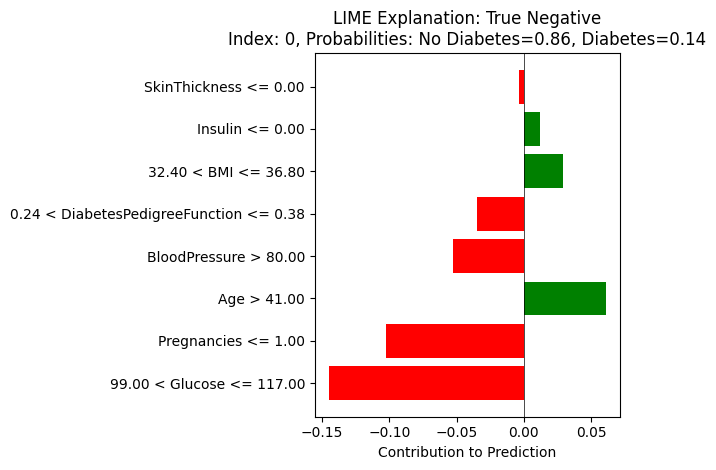

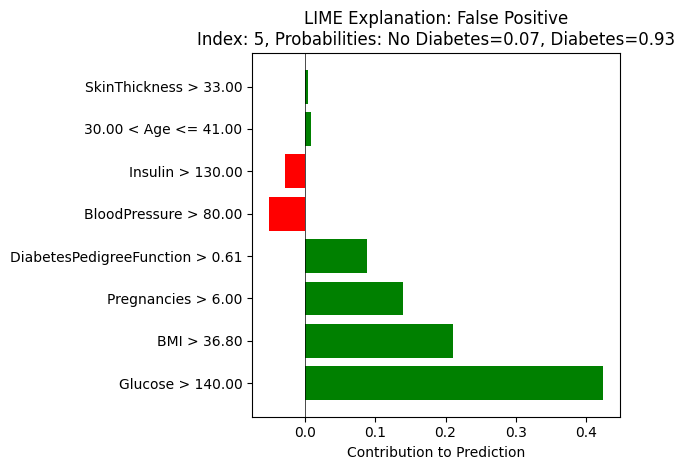

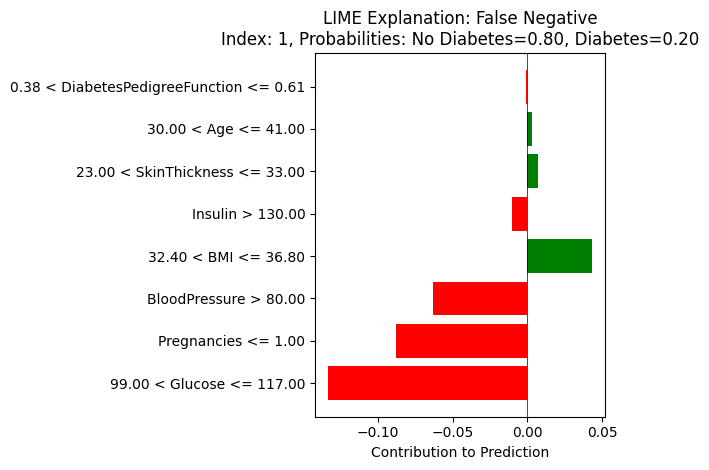

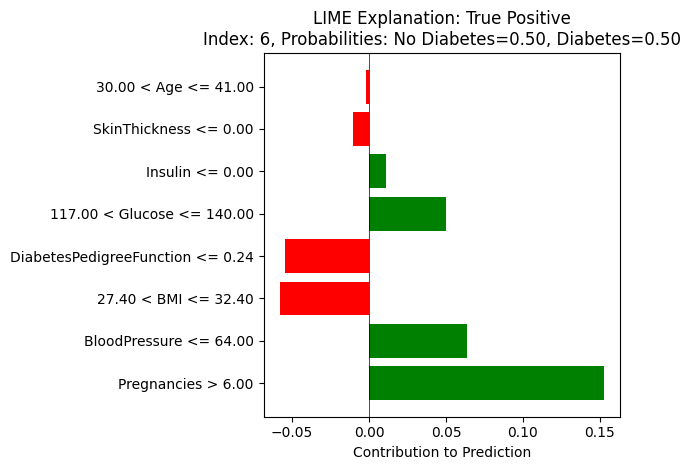

In [293]:
def plot_lime_explanation_with_details(explanation, title, index, probabilities):
    features, contributions = zip(*explanation)
    colors = ['green' if value > 0 else 'red' for value in contributions]

    plt.barh(features, contributions, color=colors)
    plt.xlabel('Contribution to Prediction')
    plt.title(f"{title}\nIndex: {index}, Probabilities: No Diabetes={probabilities[0]:.2f}, Diabetes={probabilities[1]:.2f}")
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

for case, data in results_with_probs.items():
    plot_lime_explanation_with_details(
        data['Top Features'],
        title=f"LIME Explanation: {case}",
        index=data['Index'],
        probabilities=data['Probabilities']
    )


Zadanie 2. Regresja za pomocą klasycznego modelu ML 
1. Import odpowiednich bibliotek. 
2. Przygotowanie danych.

In [294]:
housing_data = pd.read_csv('housing.csv')

housing_data_cleaned = housing_data.iloc[:, 0].str.split(expand=True)

column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]
housing_data_cleaned.columns = column_names

housing_data_cleaned.head()

housing_data_cleaned = housing_data_cleaned.apply(pd.to_numeric, errors='coerce')

housing_data_cleaned.head()
housing_data_cleaned.info()
housing_data_cleaned.isnull().sum()
housing_data_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,3.620667,11.350495,11.154257,0.069307,0.554728,6.284059,68.581584,3.794459,9.566337,408.459406,18.461782,356.594376,12.668257,22.529901
std,8.608572,23.343704,6.855868,0.254227,0.115990,0.703195,28.176371,2.107757,8.707553,168.629992,2.162520,91.367787,7.139950,9.205991
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.885000,45.000000,2.100000,4.000000,279.000000,17.400000,375.330000,7.010000,17.000000
50%,0.259150,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.199200,5.000000,330.000000,19.100000,391.430000,11.380000,21.200000
75%,3.678220,12.500000,18.100000,0.000000,0.624000,6.625000,94.100000,5.211900,24.000000,666.000000,20.200000,396.210000,16.960000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [295]:
housing_data_cleaned.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

3. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y). 
4. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 10% całego zbioru danych. Stratyfikacja ze względu na atrybut decyzyjny. Zarodek liczb losowych = 42. 

In [296]:
X = housing_data_cleaned.drop('MEDV', axis=1)
y = housing_data_cleaned['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

5.  Zbudowanie  modelu  regresji  liniowej  korzystając  z  algorytmu  regresji  opartego  na ekstremalnych drzewa losowych (klasa ExtraTreesRegressor). 
6. Wytrenowanie modelu. 
7. Wypróbowanie modelu na zbiorze testowym. 
8. Ewaluacja modelu.

In [297]:
model = ExtraTreesRegressor(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Wskaźnik R2:", r2)
print("Wskaźnik MSE:", mse)
print("Wskaźnik MAE:", mae)

Wskaźnik R2: 0.8195359304162103
Wskaźnik MSE: 6.144859156862738
Wskaźnik MAE: 1.7608039215686266


Wyjaśnienie regresji za pomocą algorytmu LIME 
1. Import odpowiednich bibliotek. 
2. Stworzenie wyjaśnienia z wykorzystaniem klasy LimeTabularExplainer. W tym celu należy stworzyć obiekt explainer, który będzie trenowany na zestawie uczącym.

In [298]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    mode='regression'
)

3. Wyjaśnienie lokalne - jakie parametry wpływają na predykcję w konkretnym przypadku? 
- wyjaśnienie  dla  4  przypadków  (jaka  jest  rzeczywista  cena  domu,  jaka  jest przewidywana  cena  domu,  jakie  cechy  wpływają  na  relatywnie  wysoką/niską  cenę domu).

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Przypadek 0:
Rzeczywista cena domu: 22.6
Przewidywana cena domu: 21.788000000000014
Cechy mające wpływ na predykcję:
  RM <= 5.88: -3.153528315950131
  CHAS <= 0.00: -1.6955618795675929
  6.86 < LSTAT <= 11.33: 1.451741233553088
  PTRATIO <= 17.00: 1.0681929238833399
  INDUS <= 5.13: 0.5649996790928203
  390.94 < B <= 395.76: 0.24076518282212295
  0.45 < NOX <= 0.54: -0.21893407806407952
  279.25 < TAX <= 330.00: -0.17074129073714708
  2.07 < DIS <= 3.17: 0.13922860927610492
  44.55 < AGE <= 77.70: 0.11721247481493319


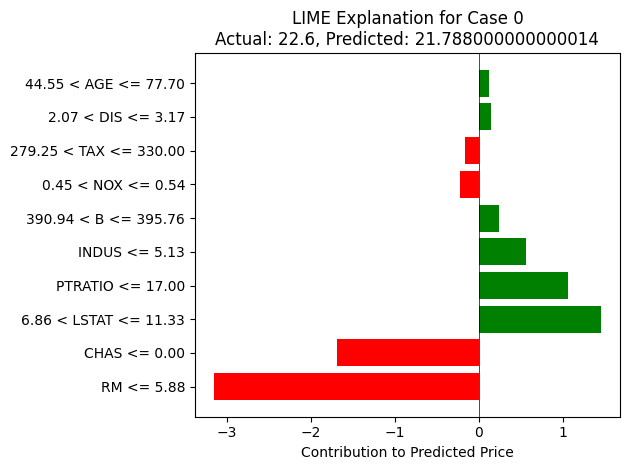

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Przypadek 1:
Rzeczywista cena domu: 32.0
Przewidywana cena domu: 31.262000000000008
Cechy mające wpływ na predykcję:
  LSTAT <= 6.86: 7.230876168613998
  RM > 6.63: 7.183409206905337
  CHAS <= 0.00: -1.7130417657846937
  TAX <= 279.25: 0.6929321111200626
  RAD <= 4.00: -0.4361091738136258
  17.00 < PTRATIO <= 19.05: 0.3887379041876682
  AGE <= 44.55: 0.3114382142055277
  ZN > 20.00: 0.14516119437624456
  NOX <= 0.45: -0.07610511466504404
  3.17 < DIS <= 5.24: -0.04198199035462456


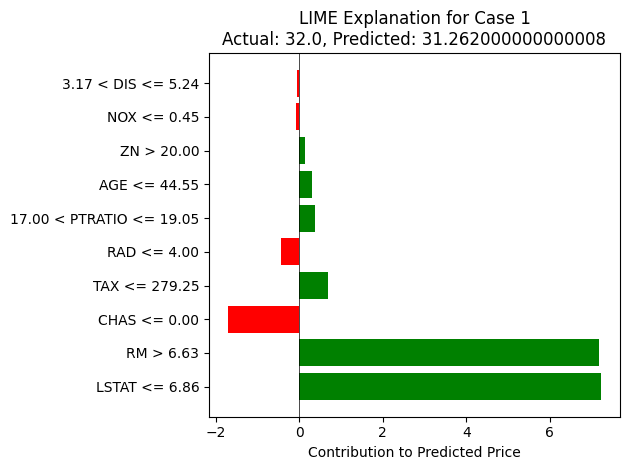

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Przypadek 2:
Rzeczywista cena domu: 13.6
Przewidywana cena domu: 16.078000000000003
Cechy mające wpływ na predykcję:
  LSTAT > 16.93: -6.096295490316652
  5.88 < RM <= 6.21: -2.984891561304146
  CHAS <= 0.00: -2.1559673623042297
  TAX > 666.00: -1.7215504558956096
  19.05 < PTRATIO <= 20.20: -0.8366757911496132
  DIS <= 2.07: 0.6091529050750709
  0.54 < NOX <= 0.63: 0.3903846226668785
  ZN <= 0.00: -0.2689760888303556
  0.08 < CRIM <= 0.27: -0.2621704036188693
  RAD <= 4.00: -0.2150876329604549


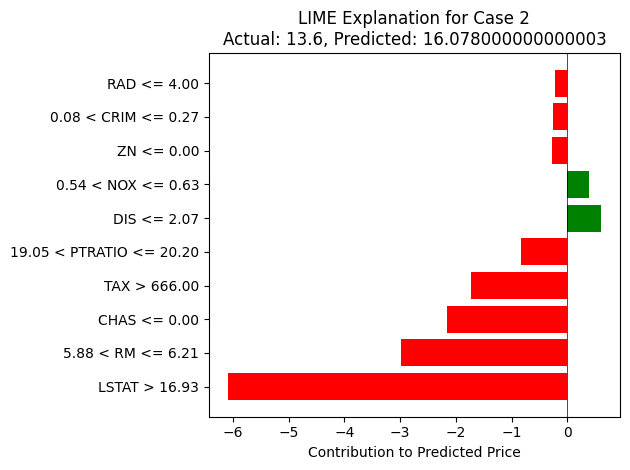

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Przypadek 3:
Rzeczywista cena domu: 23.4
Przewidywana cena domu: 23.480000000000015
Cechy mające wpływ na predykcję:
  CHAS <= 0.00: -1.9614036089757976
  6.86 < LSTAT <= 11.33: 1.5449120999905377
  6.21 < RM <= 6.63: -1.2077127021476424
  19.05 < PTRATIO <= 20.20: -0.9580547559128254
  AGE <= 44.55: 0.49504458615767966
  DIS > 5.24: -0.4300441905449531
  373.85 < B <= 390.94: 0.33277555686018423
  ZN <= 0.00: -0.27645452327431735
  0.08 < CRIM <= 0.27: -0.23157167408974155
  NOX <= 0.45: 0.08512868095756815


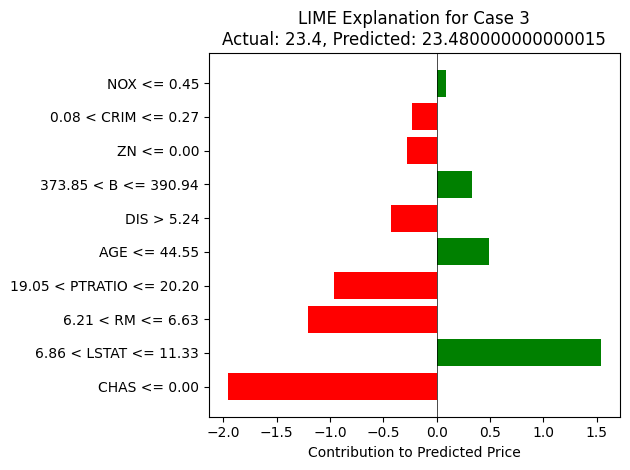

In [299]:
indices = [0, 1, 2, 3]
results_with_lime = {}

for idx in indices:
    explanation = explainer.explain_instance(
        X_test.iloc[idx].values, model.predict
    )
    actual_price = y_test.iloc[idx]
    predicted_price = predictions[idx]
    results_with_lime[idx] = {
        "Actual Price": actual_price,
        "Predicted Price": predicted_price,
        "Explanation": explanation.as_list(),
    }

    print(f"\nPrzypadek {idx}:")
    print(f"Rzeczywista cena domu: {actual_price}")
    print(f"Przewidywana cena domu: {predicted_price}")
    print("Cechy mające wpływ na predykcję:")
    for feature, contribution in explanation.as_list():
        print(f"  {feature}: {contribution}")

    features, contributions = zip(*explanation.as_list())
    colors = ['green' if value > 0 else 'red' for value in contributions]

    plt.barh(features, contributions, color=colors)
    plt.xlabel('Contribution to Predicted Price')
    plt.title(f"LIME Explanation for Case {idx}\nActual: {actual_price}, Predicted: {predicted_price}")
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

Zadanie 3. Klasyfikacja tekstu za pomocą klasycznego modelu ML 
1. Import odpowiednich bibliotek. 
2. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y).

In [300]:
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['Label', 'Message'])

X = df['Message']
y = df['Label']

df

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


3. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 25% całego zbioru danych. Stratyfikacja względem etykiet.Zarodek liczb losowych = 42

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

4. Przeprowadzenie transformacji danych tekstowych przy użyciu TF-IDF vectorizer.

In [302]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

5. Zbudowanie modelu lasów losowych. 
6. Wytrenowanie modelu. 
7. Wypróbowanie modelu na zbiorze testowym. 
8. Ewaluacja modelu na podstawie raportu z klasyfikacji i macierzy błędów.

In [303]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

print("Raport z klasyfikacji:\n", class_report)

print("\nMacierz błędów:")
print(conf_matrix)

Raport z klasyfikacji:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.98      1206
        spam       1.00      0.80      0.89       187

    accuracy                           0.97      1393
   macro avg       0.98      0.90      0.94      1393
weighted avg       0.97      0.97      0.97      1393


Macierz błędów:
[[1206    0]
 [  38  149]]


Wyjaśnienie klasyfikacji tekstu za pomocą algorytmu LIME 
1. Import odpowiednich bibliotek. 
2. Utworzenie wyjaśnienia przy pomocy klasy LimeTextExplainer, dopasowując explainer do 
danych treningowych.

In [304]:
explainer = LimeTextExplainer(class_names=model.classes_)

3. Wyjaśnienie lokalnie wyników dla 4 różnych przypadków klasyfikacji wyświetlenie etykiety rzeczywistej,  etykiety  przewidzianej  oraz  indeks  obserwacji:  True  Negative  (TN),  False Positive (FP), False Negative (FN), i True Positive (TP), uwzględniając prawdopodobieństwo i cechy mające największy wpływ na predykcję.

Brak przypadków dla klasy False Positive.

True Negative:
Index: 0
Actual Label: ham
Predicted Label: ham
Probabilities: [1. 0.]
Top Features:
  Blank: 0.0
  is: 0.0
  But: 0.0
  wat: 0.0
  blank: 0.0
  Lol: 0.0


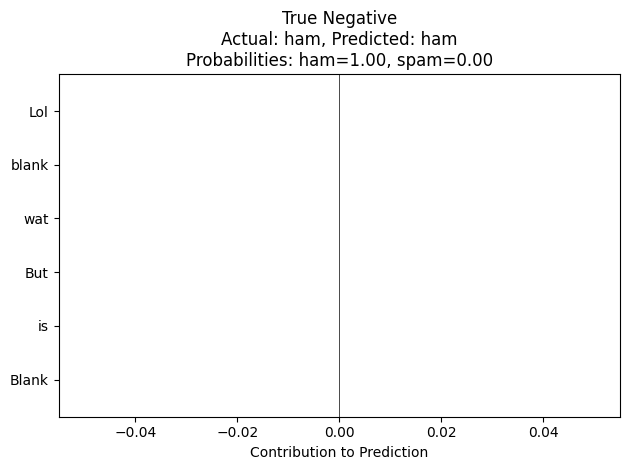


False Negative:
Index: 1
Actual Label: spam
Predicted Label: ham
Probabilities: [0.52 0.48]
Top Features:
  150p: -0.18659311687126684
  com: -0.08397731556908357
  stop: -0.06338091909023574
  to: -0.055137922031443604
  me: 0.02629540672633453
  and: 0.020333521356252774
  Text: -0.018902399615275352
  text: -0.0185625693630009
  visionsms: -0.016024435291602745
  Jordan: -0.011484008253674988


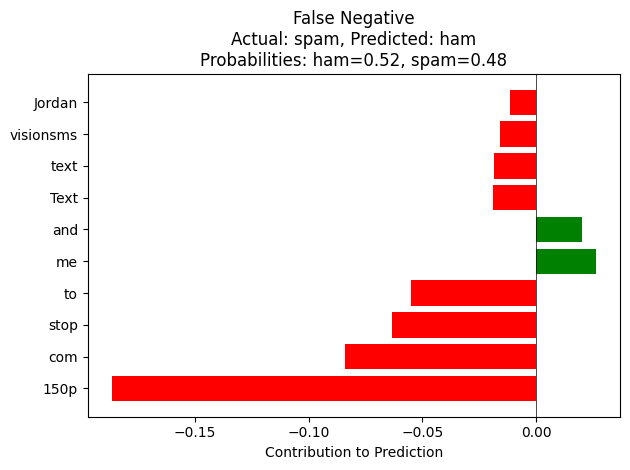


True Positive:
Index: 8
Actual Label: spam
Predicted Label: spam
Probabilities: [0.2 0.8]
Top Features:
  service: 0.17746804336397373
  100: 0.11157093438544287
  win: 0.09062923917189879
  weekly: 0.06837285595867831
  to: 0.05989662232739473
  STOP: 0.046253514260607344
  Reply: 0.04588738003928796
  end: 0.03671174986986932
  87239: 0.026893181658693362
  sport: -0.008251953371142155


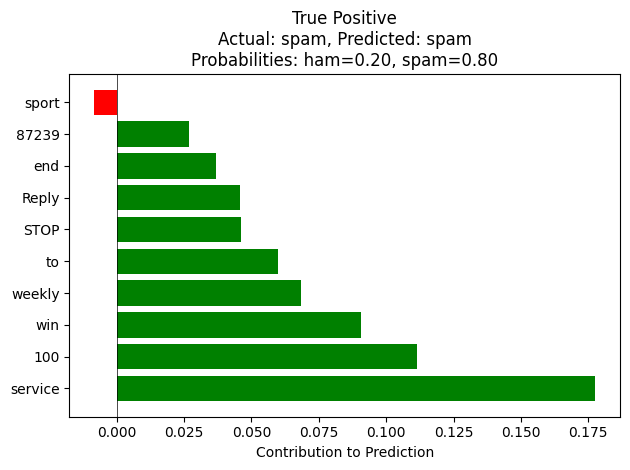

In [305]:
indices = {
    "True Negative": np.where((y_test.values == 'ham') & (predictions == 'ham'))[0],
    "False Positive": np.where((y_test.values == 'ham') & (predictions == 'spam'))[0],
    "False Negative": np.where((y_test.values == 'spam') & (predictions == 'ham'))[0],
    "True Positive": np.where((y_test.values == 'spam') & (predictions == 'spam'))[0],
}

selected_indices = {}
for case, idx_array in indices.items():
    if len(idx_array) > 0:
        selected_indices[case] = idx_array[0] 
    else:
        print(f"Brak przypadków dla klasy {case}.")

def predict_proba_wrapper(texts):
    transformed_texts = vectorizer.transform(texts)
    return model.predict_proba(transformed_texts)

results_with_lime = {}

for case, idx in selected_indices.items():
    explanation = explainer.explain_instance(
        X_test.iloc[idx],              
        predict_proba_wrapper,        
        num_features=10,              
        labels=[0, 1]               
    )
    actual_label = y_test.iloc[idx]
    predicted_label = predictions[idx]
    probabilities = model.predict_proba(X_test_tfidf[idx])[0]
    
    results_with_lime[case] = {
        "Index": idx,
        "Actual Label": actual_label,
        "Predicted Label": predicted_label,
        "Probabilities": probabilities,
        "Explanation": explanation.as_list(label=np.argmax(probabilities)),
    }
   
    print(f"\n{case}:")
    print(f"Index: {idx}")
    print(f"Actual Label: {actual_label}")
    print(f"Predicted Label: {predicted_label}")
    print(f"Probabilities: {probabilities}")
    print("Top Features:")
    for feature, contribution in results_with_lime[case]["Explanation"]:
        print(f"  {feature}: {contribution}")

    features, contributions = zip(*results_with_lime[case]["Explanation"])
    colors = ['green' if value > 0 else 'red' for value in contributions]

    plt.barh(features, contributions, color=colors)
    plt.xlabel('Contribution to Prediction')
    plt.title(f"{case}\nActual: {actual_label}, Predicted: {predicted_label}\n"
              f"Probabilities: ham={probabilities[0]:.2f}, spam={probabilities[1]:.2f}")
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()